In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

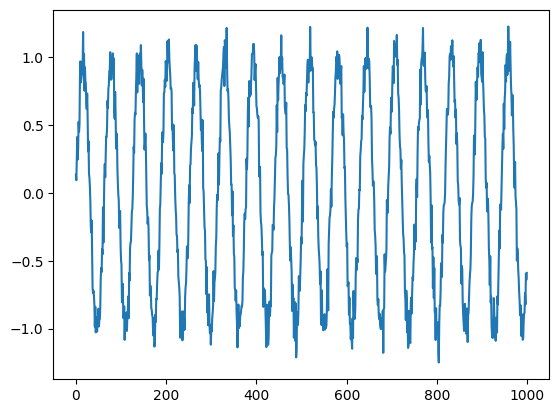

In [2]:
N = 1000
series = np.sin(0.1*np.arange(N)) + np.random.randn(N)*0.1

plt.plot(series)
plt.show()

In [3]:
#Build dataset
T = 10
X = []
Y = []

for t in range (len(series) - T):
    x = series[t:t+T]
    X.append(x)
    y = series[t+T]
    Y.append(y)
    
X = np.array(X).reshape(-1,T, 1)
Y = np.array(Y).reshape(-1,1)
N = len(X)
print(f'X-shape: {X.shape}, Y-shape: {Y.shape}')

X-shape: (990, 10, 1), Y-shape: (990, 1)


In [4]:
#set device
device = torch.device('mps')
print(device)

mps


In [5]:
#RNN class
class RNN(nn.Module):
    def __init__(self, n_inputs, n_hidden, n_rnnlayers, n_outputs):
        super(RNN, self).__init__()
        self.D = n_inputs
        self.M = n_hidden
        self.K = n_outputs
        self.L = n_rnnlayers
        
        self.rnn = nn.RNN(
            input_size= self.D,
            hidden_size= self.M,
            num_layers= self.L,
            nonlinearity='relu',
            batch_first=True)
        self.fc = nn.Linear(self.M, self.K)
        
    def forward (self,X):
        h0 = torch.zeros(self.L, X.size(0), self.M).to(device)
        
        out, _ = self.rnn(X, h0)
        out = self.fc(out[:, -1, :])
        return out

In [6]:
model = RNN(n_inputs=1, n_hidden=5 , n_rnnlayers=1, n_outputs=1)
model.to(device)

RNN(
  (rnn): RNN(1, 5, batch_first=True)
  (fc): Linear(in_features=5, out_features=1, bias=True)
)

In [7]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

In [8]:
X_train = torch.from_numpy(X[:-N//2].astype(np.float32))
X_test = torch.from_numpy(X[-N//2:].astype(np.float32))
y_train = torch.from_numpy(Y[:-N//2].astype(np.float32)) 
y_test = torch.from_numpy(Y[-N//2:].astype(np.float32))

In [9]:
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

In [10]:
#Training

def full_gd(model, criterion, optimizer, X_train, y_train, X_test, y_test, epochs=200):
    train_losses = np.zeros(epochs)
    test_losses = np.zeros(epochs)
    
    for i in range(epochs):
        optimizer.zero_grad()
        
        #Forward pass 
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        
        #Backward and optimize
        loss.backward()
        optimizer.step()
        
        #Save losses
        train_losses[i] = loss.item()
        
        #Test loss
        test_outputs = model(X_test)
        test_loss = criterion(test_outputs, y_test)
        test_losses[i] = test_loss.item()
        
        if (i + 1) % 5 == 0:
            print(f'Epoch {i+1}/{epochs}, Train loss: {loss.item():.4f}, Test loss: {test_loss.item():.4f}')
    return train_losses, test_losses

In [11]:
train_losses, test_losses = full_gd(model, criterion, optimizer, X_train, y_train, X_test, y_test)

Epoch 5/200, Train loss: 0.2996, Test loss: 0.3118
Epoch 10/200, Train loss: 0.2526, Test loss: 0.2346
Epoch 15/200, Train loss: 0.1219, Test loss: 0.0974
Epoch 20/200, Train loss: 0.0482, Test loss: 0.0498
Epoch 25/200, Train loss: 0.0694, Test loss: 0.0671
Epoch 30/200, Train loss: 0.0438, Test loss: 0.0404
Epoch 35/200, Train loss: 0.0371, Test loss: 0.0397
Epoch 40/200, Train loss: 0.0385, Test loss: 0.0371
Epoch 45/200, Train loss: 0.0293, Test loss: 0.0273
Epoch 50/200, Train loss: 0.0281, Test loss: 0.0274
Epoch 55/200, Train loss: 0.0271, Test loss: 0.0255
Epoch 60/200, Train loss: 0.0250, Test loss: 0.0244
Epoch 65/200, Train loss: 0.0251, Test loss: 0.0244
Epoch 70/200, Train loss: 0.0240, Test loss: 0.0234
Epoch 75/200, Train loss: 0.0240, Test loss: 0.0234
Epoch 80/200, Train loss: 0.0235, Test loss: 0.0230
Epoch 85/200, Train loss: 0.0233, Test loss: 0.0230
Epoch 90/200, Train loss: 0.0231, Test loss: 0.0227
Epoch 95/200, Train loss: 0.0229, Test loss: 0.0225
Epoch 100/200

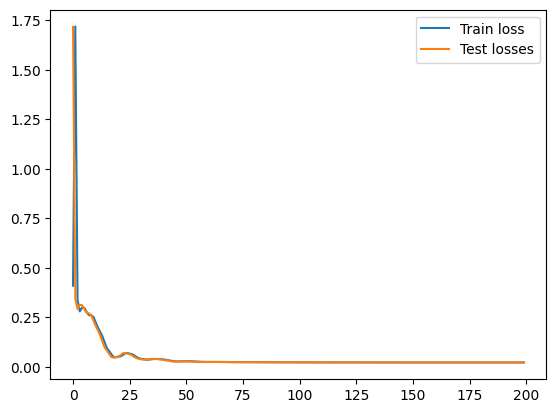

In [12]:
plt.plot(train_losses, label='Train loss')
plt.plot(test_losses, label='Test losses')
plt.legend()
plt.show()

In [13]:
#Forecast
validation_target = Y[-N//2:]
validation_predictions = []

i = 0

while len(validation_predictions) < len(validation_target):
    input_ = X_test[i].reshape(1, T, 1)
    p = model(input_)[0,0].item()
    i += 1
    
    validation_predictions.append(p)

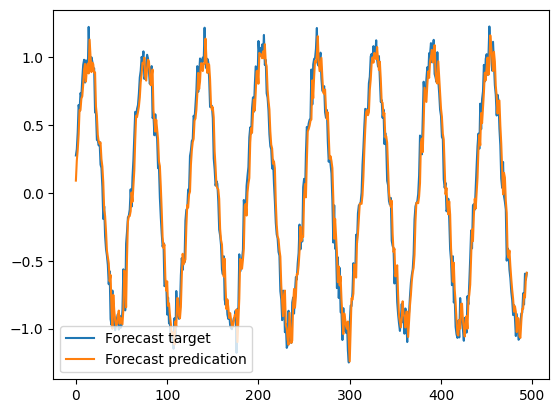

In [14]:
plt.plot(validation_target, label = 'Forecast target')
plt.plot(validation_predictions, label = 'Forecast predication')
plt.legend()